In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

# 1) Variational Principle

### Plot of analytical $\psi_0(x), \psi_1(x),$ and $\psi_2(x)$ solutions

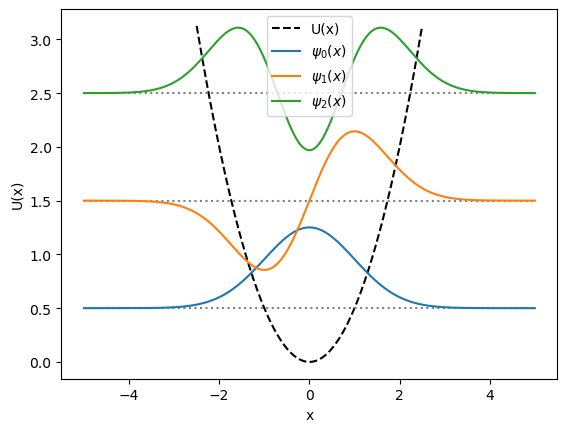

In [11]:
x_space = np.linspace(-5, 5, 500) # grid/line of x values in an array
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2) # y-values for analytical solution of n = 0 wavefunction
psi1 = np.pi**(-1/4) * (2**0.5) * x_space * np.exp(-x_space**2/2)
psi2 = np.pi**(-1/4) * (2 ** -0.5) * (2 * x_space**2 - 1) * np.exp(-x_space**2/2)

E0 = 0.5 # zero point energy
E1 = 1.5
E2 = 2.5


fig, ax = plt.subplots() # 

# plot the potential
x_space_potential = np.linspace(-2.5, 2.5, 500) # x-space grid
potential = 0.5 * x_space_potential**2
ax.plot(x_space_potential, potential, 'k--', label='U(x)')

# plot horizontle line for eigen energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the exact wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$')

ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.legend()

plt.savefig('Figures/HO_analytical.png')

### Matrix Element Evaluations (Integrals)

Given the basis functions:

$$
\phi_{\mu} (x) = \exp\left( - \alpha (x-x_A)^2\right) \\
\phi_{\nu} (x) = \exp\left( - \alpha (x-x_B)^2\right) 
$$

Note the following integrals:

$$
S_{\mu\nu} = \langle\phi_{\mu}| \phi_{\nu}\rangle = \int dx \exp\left( - \alpha (x-x_A)^2\right)
\exp \left( - \alpha (x-x_B)^2 \right)
$$

$$H_{\mu\nu} = \langle\phi_{\mu}| H |\phi_{\nu}\rangle = \int dx \exp\left( - \alpha (x-x_A)^2\right) 
\left(-\frac{d^2}{dx^2} + \frac{1}{2} x^2\right) 
\exp \left( - \alpha (x-x_B)^2 \right)$$

The analytical solutions to these integrals are:

$$
S_{\mu\nu} = \sqrt{\dfrac{\pi}{2\alpha}}
\exp \left( - \dfrac{\alpha}{2} (x_A-x_B)^2 \right)
$$

$$
H_{\mu\nu} = \dfrac{1}{2}S_{\mu\nu}
\left[
\alpha - \alpha^2(x_A-x_B)^2 + \dfrac{1}{4}(\dfrac{1}{2} + (x_A+x_B)^2)
\right]
$$

In [12]:
def S_uv_eval(xA, xB, alpha):
    return (0.5*np.pi/alpha)**0.5 * np.exp(-0.5*alpha* (xA - xB)**2 ) # fill this out    

def H_uv_eval(xA, xB, alpha):
    return 0.5* S_uv_eval(xA, xB, alpha) * (alpha - alpha**2 * (xA - xB)**2 + 0.25*(1/alpha + (xA + xB)**2 ))

### Functions for Plotting

In [13]:
def phi_A(x_space, xA, alpha=2): # compute y-values of gaussian basis function
    return np.exp(-alpha*(x_space - xA) ** 2.) # returns an array of y-values with same dimension as x_space (numpy broadcasting)

def build_wavefunction(x_space, gaussian_centers, eigvec, state_index, alpha): # build variationally optimized wavefunction from coefficients
    """
    Construct variationally minimized wavefunction from optimized coefficients

    Parameters
    ----------
    x_space : ndarray (n,)
        1D array of n gridpoints
    gaussian_centers : array-like
        Positions (centers) of the Gassian basis functions.
    eigvec : ndarray (n,n)
        Coefficient matrix
    state_index : int
        Index of the eigenstate to construct (i.e., column of `eigvec`).
    alpha : float
        Gaussian function width parameter
    Returns
    -------
    psi : ndarray
        The constructed wavefunction evaluated over `x_space`.
    """
    
    psi = np.zeros_like(x_space) # create array of zeros with same dimensions as x_space
    
    for i, xA in enumerate(gaussian_centers): # iterate over each gaussisan centers
        psi += eigvec[i, state_index] * phi_A(x_space, xA, alpha) 
    
    return psi

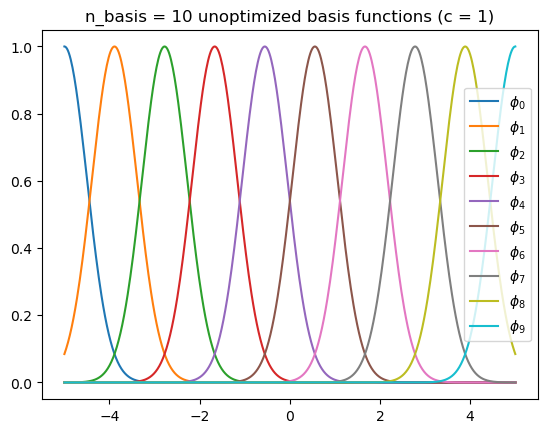

In [14]:
alpha = 2 
n_basis = 10

x_space = np.linspace(-5, 5, 500) 
gaussian_centers = np.linspace(-5, 5, n_basis)
psis = [phi_A(x_space, xA, alpha) for xA in gaussian_centers]

fig, ax = plt.subplots()
for index, psi in enumerate(psis):
    ax.plot(x_space, psi, label=rf'$\phi_{index}$')
ax.set_title('n_basis = 10 unoptimized basis functions (c = 1)')
ax.legend()


## Main Solver

[ 1.06217251  4.18747064  4.18799611 13.56262835 13.56262835]
[[-6.49278243e-06 -1.32916364e-03 -1.32925473e-03  7.51128433e-01
   7.51123103e-01]
 [-7.68824103e-03 -7.51121803e-01 -7.51085253e-01 -2.77918487e-03
  -2.77926883e-03]
 [-1.06216660e+00  8.66699073e-14  1.37726624e-02  7.37530497e-11
   2.07902190e-05]
 [-7.68824103e-03  7.51121803e-01 -7.51085253e-01  2.77916515e-03
  -2.77928855e-03]
 [-6.49278243e-06  1.32916364e-03 -1.32925473e-03 -7.51123103e-01
   7.51128432e-01]]


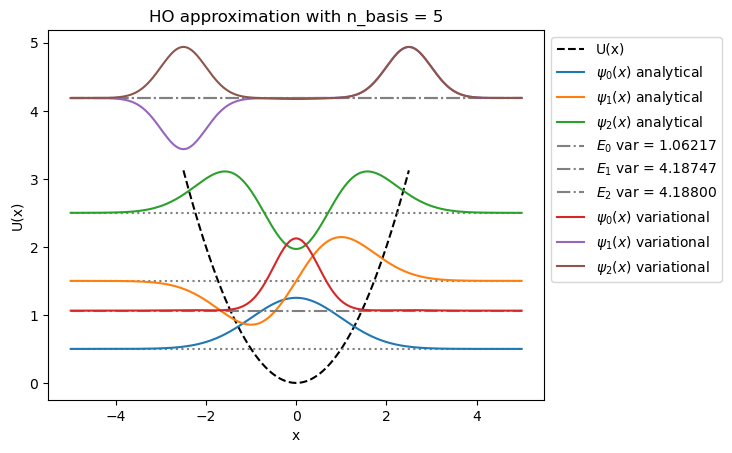

In [ ]:
alpha = 2
n_basis = 5

gaussian_centers = np.linspace(-5, 5, n_basis) # creates n_bases equally spaced between -5 to 5

S = np.zeros((n_basis, n_basis))
H = np.zeros((n_basis, n_basis))

for u, xA in enumerate(gaussian_centers):
    for v, xB in enumerate(gaussian_centers):
        S[u, v] = S_uv_eval(xA, xB, alpha)
        H[u, v] = H_uv_eval(xA, xB, alpha)

s, U = np.linalg.eigh(S) # Diagonalize S (np.linalg.eigh automatically sorts the eigenvals and eigenvecs from smallest to largest)
s_inv_sqrt = np.diag(1.0 / np.sqrt(s)) # build s^{-1/2]} (onsider using np.diag)
X = U @ s_inv_sqrt @ U.T # build orthogonalizer X = S^{-1/2}

H_prime = X.T @ H @ X # transform Hamiltonian into orthogonal basis
E, C_prime = np.linalg.eigh(H_prime) # solve TISE
C = X @ C_prime # transform eigenvector back to original basis

print(E)
print(C)

x_space = np.linspace(-5, 5, 500) 
psi0_var = build_wavefunction(x_space, gaussian_centers, C, 0, alpha) # build linear combination of basis functions with optimized coefficients 
psi1_var = build_wavefunction(x_space, gaussian_centers, C, 1, alpha)
psi2_var = build_wavefunction(x_space, gaussian_centers, C, 2, alpha)


x_space_potential = np.linspace(-2.5, 2.5, 500)
potential = 0.5 * x_space_potential**2 # y-values of HO potential 

x_space = np.linspace(-5, 5, 500) 
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2) # y-values for analytical solution of n = 0 wavefunction
psi1 = np.pi**(-1/4) * (2**0.5) * x_space * np.exp(-x_space**2/2)
psi2 = np.pi**(-1/4) * (2 ** -0.5) * (2 * x_space**2 - 1) * np.exp(-x_space**2/2)

E0 = 0.5 # zero point energy
E1 = 1.5
E2 = 2.5



fig, ax = plt.subplots() # Build Plot

# plot the potential
ax.plot(x_space_potential, potential, 'k--', label='U(x)')

# plot horizontle line for eigen energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$ analytical')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$ analytical')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$ analytical')


ax.hlines(E[0], -5, 5, colors='gray', linestyles='-.', label=f'$E_0$ var = {E[0]:.5f}')
ax.hlines(E[1], -5, 5, colors='gray', linestyles='-.', label=f'$E_1$ var = {E[1]:.5f}')
ax.hlines(E[2], -5, 5, colors='gray', linestyles='-.', label=f'$E_2$ var = {E[2]:.5f}')

ax.plot(x_space, E[0] - psi0_var, label=r'$\psi_0 (x)$ variational')
ax.plot(x_space, E[1] + psi1_var, label=r'$\psi_1 (x)$ variational')
ax.plot(x_space, E[2] - psi2_var, label=r'$\psi_2 (x)$ variational')


ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.set_title('HO approximation with n_basis = 5')
ax.legend(bbox_to_anchor=(1, 1))

plt.savefig('Figures/HO_variational_5.png', bbox_inches='tight')

[ 0.54206275  1.61633459  2.7966332   3.63620403  5.52945826  5.71616657
  9.22894623  9.24491428 14.14325178 14.14443353]
[[-5.98269652e-05  1.49458035e-04 -1.09635432e-03 -1.21930990e-03
  -4.92219396e-03 -5.71863430e-03 -3.36505642e-02 -3.43810260e-02
   7.87441640e-01 -7.87416302e-01]
 [ 3.69357953e-04 -5.06866679e-04  4.26871873e-03  1.83227390e-03
   8.80732564e-02  9.97199522e-02 -7.71954599e-01 -7.70502822e-01
  -2.83163755e-01  2.83743513e-01]
 [ 2.93520812e-03  3.22693419e-02 -1.57287302e-01 -2.67542226e-01
   7.39260306e-01  7.04359839e-01  3.28852876e-01  3.36984870e-01
   9.17947675e-02 -9.30570039e-02]
 [ 1.45937138e-01  4.32073218e-01 -7.00314424e-01 -5.31307790e-01
  -3.80985013e-01 -4.69350644e-01 -1.16448186e-01 -1.34547794e-01
  -2.91911191e-02  3.21123378e-02]
 [ 6.15488238e-01  5.68048917e-01  2.85347507e-01  6.91550110e-01
   1.05869788e-01  3.18906986e-01  2.83876421e-02  6.81220287e-02
   6.73330580e-03 -1.42910856e-02]
 [ 6.15488238e-01 -5.68048917e-01  2.85347

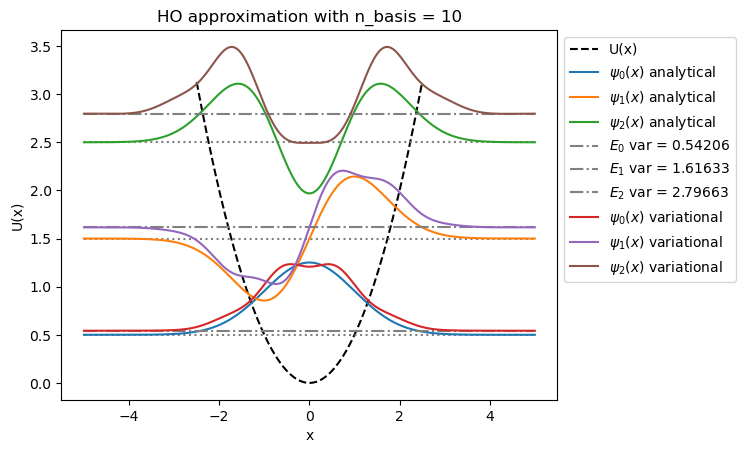

In [ ]:
alpha = 2
n_basis = 10

gaussian_centers = np.linspace(-5, 5, n_basis) # creates n_bases equally spaced between -5 to 5

S = np.zeros((n_basis, n_basis))
H = np.zeros((n_basis, n_basis))

for u, xA in enumerate(gaussian_centers):
    for v, xB in enumerate(gaussian_centers):
        S[u, v] = S_uv_eval(xA, xB, alpha)
        H[u, v] = H_uv_eval(xA, xB, alpha)

s, U = np.linalg.eigh(S) # Diagonalize S (np.linalg.eigh automatically sorts the eigenvals and eigenvecs from smallest to largest)
s_inv_sqrt = np.diag(1.0 / np.sqrt(s)) # build s^{-1/2]} (onsider using np.diag)
X = U @ s_inv_sqrt @ U.T # build orthogonalizer X = S^{-1/2}

H_prime = X.T @ H @ X # transform Hamiltonian into orthogonal basis
E, C_prime = np.linalg.eigh(H_prime) # solve TISE
C = X @ C_prime # transform eigenvector back to original basis

print(E)
print(C)

x_space = np.linspace(-5, 5, 500) 
psi0_var = build_wavefunction(x_space, gaussian_centers, C, 0, alpha) # build linear combination of basis functions with optimized coefficients 
psi1_var = build_wavefunction(x_space, gaussian_centers, C, 1, alpha)
psi2_var = build_wavefunction(x_space, gaussian_centers, C, 2, alpha)


x_space_potential = np.linspace(-2.5, 2.5, 500)
potential = 0.5 * x_space_potential**2 # y-values of HO potential 

x_space = np.linspace(-5, 5, 500) 
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2) # y-values for analytical solution of n = 0 wavefunction
psi1 = np.pi**(-1/4) * (2**0.5) * x_space * np.exp(-x_space**2/2)
psi2 = np.pi**(-1/4) * (2 ** -0.5) * (2 * x_space**2 - 1) * np.exp(-x_space**2/2)

E0 = 0.5 # zero point energy
E1 = 1.5
E2 = 2.5



fig, ax = plt.subplots() # Build Plot

# plot the potential
ax.plot(x_space_potential, potential, 'k--', label='U(x)')

# plot horizontle line for eigen energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$ analytical')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$ analytical')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$ analytical')


ax.hlines(E[0], -5, 5, colors='gray', linestyles='-.', label=f'$E_0$ var = {E[0]:.5f}')
ax.hlines(E[1], -5, 5, colors='gray', linestyles='-.', label=f'$E_1$ var = {E[1]:.5f}')
ax.hlines(E[2], -5, 5, colors='gray', linestyles='-.', label=f'$E_2$ var = {E[2]:.5f}')

ax.plot(x_space, E[0] + psi0_var, label=r'$\psi_0 (x)$ variational')
ax.plot(x_space, E[1] - psi1_var, label=r'$\psi_1 (x)$ variational')
ax.plot(x_space, E[2] - psi2_var, label=r'$\psi_2 (x)$ variational')


ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.set_title('HO approximation with n_basis = 10')
ax.legend(bbox_to_anchor=(1, 1))

plt.savefig('Figures/HO_variational_10.png', bbox_inches='tight')

[ 0.50002168  1.5001921   2.50097562  3.50382625  4.51077058  5.53236701
  6.54820597  7.66078561  8.56295259 10.03522127 10.52535666 12.81276705
 12.97010906 16.11219922 16.16078372]
[[ 1.83914538e-08 -1.72776918e-05  1.92712655e-05 -2.34421070e-04
  -4.35319801e-04  1.02170837e-03  2.31321495e-03 -5.08792648e-03
   1.57967267e-02  2.16798152e-02 -1.71727288e-02 -1.86786244e-01
  -2.10705279e-01  1.02765926e+00 -1.02384077e+00]
 [ 2.35889086e-06  6.95874899e-05 -1.69653352e-04  1.70600970e-04
  -6.38181589e-04 -9.37557635e-03 -2.53885332e-02 -3.96984457e-02
   6.13301056e-02  2.83634957e-01 -3.71268731e-01 -8.05378210e-01
  -7.49165284e-01 -1.14818417e+00  1.16502860e+00]
 [ 1.00622350e-04  5.65007731e-04 -2.95421548e-03 -1.26044950e-02
  -3.61104681e-02 -7.87484017e-02 -1.66625727e-01 -3.89960226e-01
   5.68051388e-01  6.28498117e-01 -3.82922079e-01  1.08919229e+00
   1.10153870e+00  8.67182051e-01 -9.07157155e-01]
 [ 2.13760051e-03  1.17603038e-02 -4.18378217e-02 -1.10982335e-01
  -

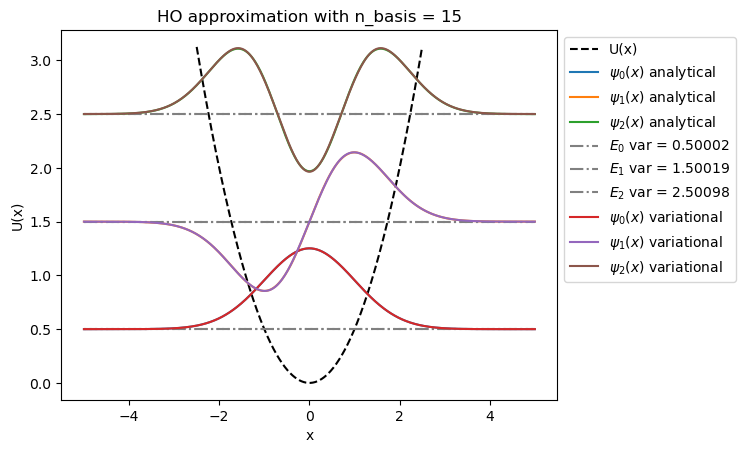

In [ ]:
alpha = 2
n_basis = 15

gaussian_centers = np.linspace(-5, 5, n_basis) # creates n_bases equally spaced between -5 to 5

S = np.zeros((n_basis, n_basis))
H = np.zeros((n_basis, n_basis))

for u, xA in enumerate(gaussian_centers):
    for v, xB in enumerate(gaussian_centers):
        S[u, v] = S_uv_eval(xA, xB, alpha)
        H[u, v] = H_uv_eval(xA, xB, alpha)

s, U = np.linalg.eigh(S) # Diagonalize S (np.linalg.eigh automatically sorts the eigenvals and eigenvecs from smallest to largest)
s_inv_sqrt = np.diag(1.0 / np.sqrt(s)) # build s^{-1/2]} (onsider using np.diag)
X = U @ s_inv_sqrt @ U.T # build orthogonalizer X = S^{-1/2}

H_prime = X.T @ H @ X # transform Hamiltonian into orthogonal basis
E, C_prime = np.linalg.eigh(H_prime) # solve TISE
C = X @ C_prime # transform eigenvector back to original basis

print(E)
print(C)

x_space = np.linspace(-5, 5, 500) 
psi0_var = build_wavefunction(x_space, gaussian_centers, C, 0, alpha) # build linear combination of basis functions with optimized coefficients 
psi1_var = build_wavefunction(x_space, gaussian_centers, C, 1, alpha)
psi2_var = build_wavefunction(x_space, gaussian_centers, C, 2, alpha)


x_space_potential = np.linspace(-2.5, 2.5, 500)
potential = 0.5 * x_space_potential**2 # y-values of HO potential 

x_space = np.linspace(-5, 5, 500) 
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2) # y-values for analytical solution of n = 0 wavefunction
psi1 = np.pi**(-1/4) * (2**0.5) * x_space * np.exp(-x_space**2/2)
psi2 = np.pi**(-1/4) * (2 ** -0.5) * (2 * x_space**2 - 1) * np.exp(-x_space**2/2)

E0 = 0.5 # zero point energy
E1 = 1.5
E2 = 2.5



fig, ax = plt.subplots() # Build Plot

# plot the potential
ax.plot(x_space_potential, potential, 'k--', label='U(x)')

# plot horizontle line for eigen energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$ analytical')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$ analytical')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$ analytical')


ax.hlines(E[0], -5, 5, colors='gray', linestyles='-.', label=f'$E_0$ var = {E[0]:.5f}')
ax.hlines(E[1], -5, 5, colors='gray', linestyles='-.', label=f'$E_1$ var = {E[1]:.5f}')
ax.hlines(E[2], -5, 5, colors='gray', linestyles='-.', label=f'$E_2$ var = {E[2]:.5f}')

ax.plot(x_space, E[0] + psi0_var, label=r'$\psi_0 (x)$ variational')
ax.plot(x_space, E[1] - psi1_var, label=r'$\psi_1 (x)$ variational')
ax.plot(x_space, E[2] - psi2_var, label=r'$\psi_2 (x)$ variational')


ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.set_title('HO approximation with n_basis = 15')
ax.legend(bbox_to_anchor=(1, 1))

plt.savefig('Figures/HO_variational_15.png', bbox_inches='tight')

[ 0.5         1.5         2.50000003  3.50000022  4.50000119  5.50000554
  6.50002296  7.50008266  8.50028795  9.50080343 10.50260242 11.50524595
 12.51744771 13.52001456 14.58891412 15.56654616 16.8806021  17.64366329
 19.779185   20.30150011]
[[ 2.55904615e-08 -2.22153858e-07  1.19815920e-06  6.65350202e-06
  -3.49405123e-05 -1.35022604e-04 -4.11100237e-04  1.27647526e-03
  -4.10326443e-03  1.11069311e-02  2.45373302e-02  5.19413801e-02
   1.15477850e-01  2.27343678e-01 -3.84697748e-01 -5.22379973e-01
  -8.78513164e-01 -1.02181278e+00  1.49592233e+00 -1.35390045e+00]
 [ 5.72079957e-07 -4.87425258e-06  2.91669880e-05  1.34430192e-04
  -5.09353046e-04 -1.72501365e-03 -5.32895142e-03  1.43129101e-02
  -3.30261489e-02  6.97012953e-02  1.40055936e-01  2.47394814e-01
   3.49971464e-01  3.89093274e-01 -3.80943650e-01 -2.29271111e-01
   6.05638962e-01  1.36667827e+00 -3.53532239e+00  3.36647833e+00]
 [ 1.12441214e-05 -8.36197651e-05  4.25349119e-04  1.71531486e-03
  -5.79931485e-03 -1.674773

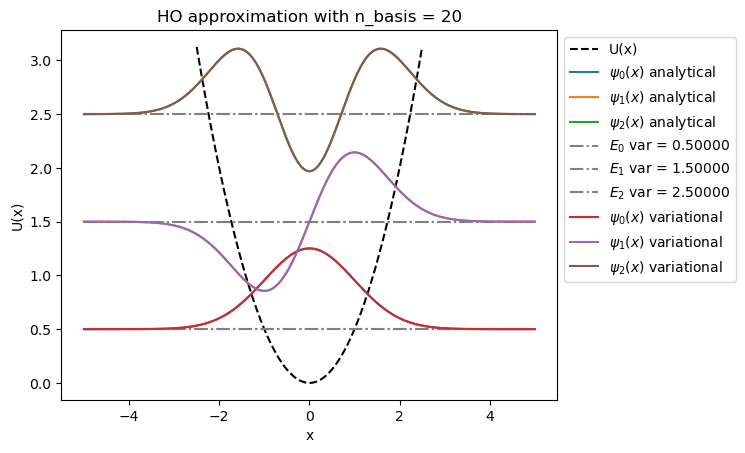

In [ ]:
alpha = 2
n_basis = 20

gaussian_centers = np.linspace(-5, 5, n_basis) # creates n_bases equally spaced between -5 to 5

S = np.zeros((n_basis, n_basis))
H = np.zeros((n_basis, n_basis))

for u, xA in enumerate(gaussian_centers):
    for v, xB in enumerate(gaussian_centers):
        S[u, v] = S_uv_eval(xA, xB, alpha)
        H[u, v] = H_uv_eval(xA, xB, alpha)

s, U = np.linalg.eigh(S) # Diagonalize S (np.linalg.eigh automatically sorts the eigenvals and eigenvecs from smallest to largest)
s_inv_sqrt = np.diag(1.0 / np.sqrt(s)) # build s^{-1/2]} (onsider using np.diag)
X = U @ s_inv_sqrt @ U.T # build orthogonalizer X = S^{-1/2}

H_prime = X.T @ H @ X # transform Hamiltonian into orthogonal basis
E, C_prime = np.linalg.eigh(H_prime) # solve TISE
C = X @ C_prime # transform eigenvector back to original basis

print(E)
print(C)

x_space = np.linspace(-5, 5, 500) 
psi0_var = build_wavefunction(x_space, gaussian_centers, C, 0, alpha) # build linear combination of basis functions with optimized coefficients 
psi1_var = build_wavefunction(x_space, gaussian_centers, C, 1, alpha)
psi2_var = build_wavefunction(x_space, gaussian_centers, C, 2, alpha)


x_space_potential = np.linspace(-2.5, 2.5, 500)
potential = 0.5 * x_space_potential**2 # y-values of HO potential 

x_space = np.linspace(-5, 5, 500) 
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2) # y-values for analytical solution of n = 0 wavefunction
psi1 = np.pi**(-1/4) * (2**0.5) * x_space * np.exp(-x_space**2/2)
psi2 = np.pi**(-1/4) * (2 ** -0.5) * (2 * x_space**2 - 1) * np.exp(-x_space**2/2)

E0 = 0.5 # zero point energy
E1 = 1.5
E2 = 2.5



fig, ax = plt.subplots() # Build Plot

# plot the potential
ax.plot(x_space_potential, potential, 'k--', label='U(x)')

# plot horizontle line for eigen energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$ analytical')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$ analytical')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$ analytical')


ax.hlines(E[0], -5, 5, colors='gray', linestyles='-.', label=f'$E_0$ var = {E[0]:.5f}')
ax.hlines(E[1], -5, 5, colors='gray', linestyles='-.', label=f'$E_1$ var = {E[1]:.5f}')
ax.hlines(E[2], -5, 5, colors='gray', linestyles='-.', label=f'$E_2$ var = {E[2]:.5f}')

ax.plot(x_space, E[0] + psi0_var, label=r'$\psi_0 (x)$ variational')
ax.plot(x_space, E[1] + psi1_var, label=r'$\psi_1 (x)$ variational')
ax.plot(x_space, E[2] + psi2_var, label=r'$\psi_2 (x)$ variational')


ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.set_title('HO approximation with n_basis = 20')
ax.legend(bbox_to_anchor=(1, 1))

plt.savefig('Figures/HO_variational_20.png', bbox_inches='tight')

# 2) Correlation

The integral for the coupled oscillator component evaluates to:

$$G_{\mu\nu} =  \langle\phi_\mu| x^4 | \phi_\nu\rangle = \int dx \exp\left( - \alpha (x-x_A)^2\right) 
\left(x^4\right) 
\exp \left( - \alpha (x-x_B)^2 \right)$$

$$
    G_{\mu\nu} = S_{\mu\nu} \left[
    \dfrac{3}{16\alpha^2} + \dfrac{3}{8\alpha}(x_A+x_B)^2 + \dfrac{1}{16} (x_A+x_B)^4
    \right]
$$

In [19]:
def S_uv_eval(xA, xB, alpha):
    return (0.5*np.pi/alpha)**0.5 * np.exp(-0.5*alpha* (xA - xB)**2 ) # fill this out    

def H_uv_eval(xA, xB, alpha):
    return 0.5* S_uv_eval(xA, xB, alpha) * (alpha - alpha**2 * (xA - xB)**2 + 0.25*(1/alpha + (xA + xB)**2 ))

def G_uv_func(xA, xB, alpha):
    return S_uv_eval(xA, xB, alpha) * ( 3/(16*alpha**2) + (3/(8*alpha)) * (xA + xB)**2 + (1/16) * (xA + xB)**4)

## Build Integrals and Orthogonalizer

In [20]:
alpha = 2
n_basis = 20
gaussian_centers = np.linspace(-5, 5, n_basis)

S = np.zeros((n_basis, n_basis))
H = np.zeros((n_basis, n_basis))
G = np.zeros((n_basis, n_basis))

for u, xA in enumerate(gaussian_centers):
    for v, xB in enumerate(gaussian_centers):
        S[u, v] = S_uv_eval(xA, xB, alpha)
        H[u, v] = H_uv_eval(xA, xB, alpha)
        G[u, v] = G_uv_func(xA, xB, alpha)

s, U = np.linalg.eigh(S)
s_inv_sqrt = np.diag(1.0 / np.sqrt(s))
X = U @ s_inv_sqrt @ U.T

## SCF loop

In [38]:
def initial_guess():
    H_prime = X.T @ H @ X
    _, C_prime = np.linalg.eigh(H_prime)
    C = X @ C_prime 

    return C

def SCF(Cx, Cy, a, outfile, epsilon=1e-8, maxIter=200):
    i = 0
    diff = np.eye(2) # Fro norm of a 2x2 matrix is sqrt(2), any random matrix picked to intentionally fail the while loop condition
    Heffx_old = np.zeros_like(H) # initialize zero matrix with dimensions of Heffy_new, again to create the largest possible diff

    with open(outfile, "w") as f:
        while i < maxIter and np.linalg.norm(diff, ord='fro') > epsilon:
            avx4 = Cy[:,0] @ G @ Cy[:,0] # this means to get the 0th element of each subarray of Cx and Cy, building the first column vector
            avy4 = Cx[:,0] @ G @ Cx[:,0]

            Heffx_new = H + a * avy4 * G
            Heffy_new = H + a * avx4 * G
            
            Heffx_p = X.T @ Heffx_new @ X
            Ex, Cx_p = np.linalg.eigh(Heffx_p)
            Cx = X @ Cx_p 

            Heffy_p = X.T @ Heffy_new @ X
            Ey, Cy_p = np.linalg.eigh(Heffy_p)
            Cy = X @ Cy_p 

            E = Ex[0] + Ey[0] - (a * avx4 * avy4)
            diff = Heffx_new - Heffx_old
            Heffx_old = Heffx_new

            f.write(f"iteration: {i}\n")
            f.write(f"\t Energy: {E}\n")
            f.write(f"\t Tolerance: {np.linalg.norm(diff, ord='fro')}\n")

            i += 1
        if i < maxIter:
            f.write("SCF Converged\n")
        elif i == maxIter:
            f.write("Max Iterations Reached\n")
    return E, Cx, Cy

In [43]:
aa = [0, 0.1, 1, 10, 100, 1000]

for a in aa:
    n_basis = 20
    maxIter = 200
    epsilon = 1e-8

    # Initial guess wavefunction for particle in x and particle in y
    C = initial_guess()
    Cx = C.copy()
    Cy = C.copy()

    outfile = f'output/output_a={a}.txt'
    E, Cx, Cy = SCF(Cx, Cy, a, outfile)
    print(f'a = {a}, E = {E}')


a = 0, E = 1.0000000003979397
a = 0.1, E = 1.0407920206484829
a = 1, E = 1.186549277849942
a = 10, E = 1.5449222490711876
a = 100, E = 2.2317616708156742
a = 1000, E = 3.4100729022053393
